# HW 1: Financial Data Cleaning, Exploratory Analysis, and Risk Indicators
## RBS: Foundations of Business Programming
**Due Date:** April 21, 2026  
**Estimated Time Commitment:** 5–6 Hours


### **CONGRATULATIONS!!**

You have been hired as a **Junior Data Analyst** at  FinTech Co. Inc, (a totally above board lending company! Trust us!).

The Risk Analytics team wants to build a future machine learning model to help predict whether a borrower is likely to repay a loan. Before that can happen, the company needs someone to clean the raw data, build a few useful risk indicators, and summarize what matters.

Your job in this homework is to:
- clean several messy columns,
- perform exploratory analysis,
- create a few charts,
- and prepare a model-ready dataset for a future machine learning assignment.

This homework is designed for **Google Colab** and is fully self-contained.


### Why the 6 hour time commitment?


This assignment is not hard because the math is advanced. It takes time because real-world data is messy.

You should expect to spend a good amount of time:
- checking column types,
- dealing with inconsistent strings,
- handling missing values,
- grouping and summarizing correctly,
- and making sure your charts match your analysis.

That is normal. In real data work, cleaning and verification often take longer than the final analysis.


### Rules "the man" makes us follow, otherwise we get a fine

- You may use **pandas**, **matplotlib**, and **seaborn**.
- Unless a task says otherwise, you may choose your own reasonable coding approach.
- For **Task 1**, you are **not allowed to use regular expressions**.
- Show your work clearly. Do not just compute an answer and move on.
- Label charts clearly.
- Write short interpretations under your results when asked.


### Part 0: Environment Setup

Run the following cell to load the dataset and inspect the raw data.
This version uses a public Lending Club CSV that contains loan-level observations with both borrower information and repayment outcomes.


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 20)

# Load dataset
url = "https://raw.githubusercontent.com/akshayr89/Lending-Club---Exploratory-Data-Analysis/master/loan.csv"
df = pd.read_csv(url, low_memory=False)

print("Data successfully loaded.")
print("Shape:", df.shape)
display(df.head())
print("\nSelected columns:")
print([
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "issue_d",
    "loan_status",
    "purpose",
    "addr_state"
])


Data successfully loaded.
Shape: (39717, 111)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,...,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,1,NaN,NaN,3,0,13648,83.70%,9,f,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,NaN,May-16,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0,Apr-99,5,NaN,NaN,3,0,1687,9.40%,4,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,2,NaN,NaN,2,0,2956,98.50%,10,f,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,NaN,May-16,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0,Feb-96,1,35.0,NaN,10,0,5598,21%,37,f,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,NaN,Apr-16,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,


Selected columns:
['loan_amnt', 'term', 'int_rate', 'emp_length', 'home_ownership', 'annual_inc', 'issue_d', 'loan_status', 'purpose', 'addr_state']


In [ ]:
df_lec = df[['loan_amnt','term','int_rate','emp_length','annual_inc','purpose', 'addr_state', 'loan_status','issue_d']]
print(df_lec)

       loan_amnt        term int_rate emp_length  annual_inc  \
0           5000   36 months   10.65%  10+ years     24000.0   
1           2500   60 months   15.27%   < 1 year     30000.0   
2           2400   36 months   15.96%  10+ years     12252.0   
3          10000   36 months   13.49%  10+ years     49200.0   
4           3000   60 months   12.69%     1 year     80000.0   
...          ...         ...      ...        ...         ...   
39712       2500   36 months    8.07%    4 years    110000.0   
39713       8500   36 months   10.28%    3 years     18000.0   
39714       5000   36 months    8.07%   < 1 year    100000.0   
39715       5000   36 months    7.43%   < 1 year    200000.0   
39716       7500   36 months   13.75%   < 1 year     22000.0   

                  purpose addr_state  loan_status issue_d  
0             credit_card         AZ   Fully Paid  Dec-11  
1                     car         GA  Charged Off  Dec-11  
2          small_business         IL   Fully Paid  

In [ ]:
print(df['emp_length'].value_counts(dropna=False))
print(df['emp_length'].value_counts(dropna=False).sort_index())
def_lec = df['emp_length'].value_counts(dropna=False).sort_index()

emp_length
10+ years    8879
< 1 year     4583
2 years      4388
3 years      4095
4 years      3436
5 years      3282
1 year       3240
6 years      2229
7 years      1773
8 years      1479
9 years      1258
NaN          1075
Name: count, dtype: int64
emp_length
1 year       3240
10+ years    8879
2 years      4388
3 years      4095
4 years      3436
5 years      3282
6 years      2229
7 years      1773
8 years      1479
9 years      1258
< 1 year     4583
NaN          1075
Name: count, dtype: int64


In [ ]:
df_lec['emp_length_clean'] = df_lec['emp_length'].copy()
# here we are replacing the EXACT string "10+ years" with the string "10"
df_lec['emp_length_clean'] = df_lec['emp_length_clean'].replace("10+ years", "10")
df_lec['emp_length_clean'] = df_lec['emp_length_clean'].replace("< 1 year", "0")
df_lec['emp_length_clean'] = df_lec['emp_length_clean'].replace("1 year", "1")


# for each value in the column, replace the SUBSTRING " years" with nothing ""
df_lec['emp_length_clean'] = df_lec['emp_length_clean'].str.replace(" years", "")

# After this, the column's values are clean, but their type is not.
# They are strings, we want them to be integers
df_lec['emp_length_clean'] = pd.to_numeric(df_lec['emp_length_clean'], errors='coerce')

# here we will replace the NaN with the mode (most commonly occuring) value of the column
emperical_mode = df_lec['emp_length_clean'].mode(0)
df_lec['emp_length_clean'] = df_lec['emp_length_clean'].fillna(emperical_mode)
print(f'here\'s the emperical (what we calculate from the data) mode {emperical_mode}')

df_lec['emp_length_clean'].value_counts()

here's the emperical (what we calculate from the data) mode 0    10.0
Name: emp_length_clean, dtype: float64


/tmp/ipykernel_41659/3027849532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['emp_length_clean'] = df_lec['emp_length'].copy()
/tmp/ipykernel_41659/3027849532.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['emp_length_clean'] = df_lec['emp_length_clean'].replace("10+ years", "10")
/tmp/ipykernel_41659/3027849532.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,count
emp_length_clean,
10.0,8879
0.0,4583
2.0,4388
3.0,4095
4.0,3436
5.0,3282
1.0,3240
6.0,2229
7.0,1773


In [ ]:
df_lec

,loan_amnt,term,int_rate,emp_length,annual_inc,purpose,addr_state,loan_status,issue_d,emp_length_clean
0,5000,36 months,10.65%,10+ years,24000.0,credit_card,AZ,Fully Paid,Dec-11,10.0
1,2500,60 months,15.27%,< 1 year,30000.0,car,GA,Charged Off,Dec-11,0.0
2,2400,36 months,15.96%,10+ years,12252.0,small_business,IL,Fully Paid,Dec-11,10.0
3,10000,36 months,13.49%,10+ years,49200.0,other,CA,Fully Paid,Dec-11,10.0
4,3000,60 months,12.69%,1 year,80000.0,other,OR,Current,Dec-11,1.0
...,...,...,...,...,...,...,...,...,...,...
39712,2500,36 months,8.07%,4 years,110000.0,home_improvement,CO,Fully Paid,Jul-07,4.0
39713,8500,36 months,10.28%,3 years,18000.0,credit_card,NC,Fully Paid,Jul-07,3.0
39714,5000,36 months,8.07%,< 1 year,100000.0,debt_consolidation,MA,Fully Paid,Jul-07,0.0
39715,5000,36 months,7.43%,< 1 year,200000.0,other,MD,Fully Paid,Jul-07,0.0


In [ ]:
df_lec['int_rate_clean'] = df_lec['int_rate'].copy()

# for each value in the column, replace the SUBSTRING " years" with nothing ""
df_lec['int_rate_clean'] = df_lec['int_rate_clean'].str.replace("%", "")

# After this, the column's values are clean, but their type is not.
# They are strings, we want them to be integers
df_lec['int_rate_clean'] = pd.to_numeric(df_lec['int_rate_clean'], errors='coerce')

df_lec

/tmp/ipykernel_41659/490271876.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['int_rate_clean'] = df_lec['int_rate'].copy()
/tmp/ipykernel_41659/490271876.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['int_rate_clean'] = df_lec['int_rate_clean'].str.replace("%", "")
/tmp/ipykernel_41659/490271876.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

,loan_amnt,term,int_rate,emp_length,annual_inc,purpose,addr_state,loan_status,issue_d,emp_length_clean,int_rate_clean
0,5000,36 months,10.65%,10+ years,24000.0,credit_card,AZ,Fully Paid,Dec-11,10.0,10.65
1,2500,60 months,15.27%,< 1 year,30000.0,car,GA,Charged Off,Dec-11,0.0,15.27
2,2400,36 months,15.96%,10+ years,12252.0,small_business,IL,Fully Paid,Dec-11,10.0,15.96
3,10000,36 months,13.49%,10+ years,49200.0,other,CA,Fully Paid,Dec-11,10.0,13.49
4,3000,60 months,12.69%,1 year,80000.0,other,OR,Current,Dec-11,1.0,12.69
...,...,...,...,...,...,...,...,...,...,...,...
39712,2500,36 months,8.07%,4 years,110000.0,home_improvement,CO,Fully Paid,Jul-07,4.0,8.07
39713,8500,36 months,10.28%,3 years,18000.0,credit_card,NC,Fully Paid,Jul-07,3.0,10.28
39714,5000,36 months,8.07%,< 1 year,100000.0,debt_consolidation,MA,Fully Paid,Jul-07,0.0,8.07
39715,5000,36 months,7.43%,< 1 year,200000.0,other,MD,Fully Paid,Jul-07,0.0,7.43


In [ ]:
df_lec['loan_status'].value_counts()
# here "Charged Off" means that the lender stopped collecting on the loan, they
# gave up and considered it a wash. This is a bad loan.
# A good loan are the ones Fully Paid

,count
loan_status,
Fully Paid,32950
Charged Off,5627
Current,1140


In [ ]:
# this creates a binary (0/1) column for bad loans (1) vs not bad loans (0)
df_lec['default_flag'] = (df_lec['loan_status'] == 'Charged Off').astype(int)

df_lec


/tmp/ipykernel_41659/2465069895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['default_flag'] = (df_lec['loan_status'] == 'Charged Off').astype(int)


,loan_amnt,term,int_rate,emp_length,annual_inc,purpose,addr_state,loan_status,issue_d,emp_length_clean,int_rate_clean,issed_d_datetime,issed_d_year,issed_d_month,default_flag
0,5000,36 months,10.65%,10+ years,24000.0,credit_card,AZ,Fully Paid,Dec-11,10.0,10.65,2011-12-01,2011,12,0
1,2500,60 months,15.27%,< 1 year,30000.0,car,GA,Charged Off,Dec-11,0.0,15.27,2011-12-01,2011,12,1
2,2400,36 months,15.96%,10+ years,12252.0,small_business,IL,Fully Paid,Dec-11,10.0,15.96,2011-12-01,2011,12,0
3,10000,36 months,13.49%,10+ years,49200.0,other,CA,Fully Paid,Dec-11,10.0,13.49,2011-12-01,2011,12,0
4,3000,60 months,12.69%,1 year,80000.0,other,OR,Current,Dec-11,1.0,12.69,2011-12-01,2011,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,2500,36 months,8.07%,4 years,110000.0,home_improvement,CO,Fully Paid,Jul-07,4.0,8.07,2007-07-01,2007,7,0
39713,8500,36 months,10.28%,3 years,18000.0,credit_card,NC,Fully Paid,Jul-07,3.0,10.28,2007-07-01,2007,7,0
39714,5000,36 months,8.07%,< 1 year,100000.0,debt_consolidation,MA,Fully Paid,Jul-07,0.0,8.07,2007-07-01,2007,7,0
39715,5000,36 months,7.43%,< 1 year,200000.0,other,MD,Fully Paid,Jul-07,0.0,7.43,2007-07-01,2007,7,0


In [ ]:
# this is doing analysis

# I want to know which years had the most loans (count)
# WHich years had the most dollars issues? (sum)

# groupby means that you sort the table according to that column
# agg means that for each collection of rows with the same value, they get collapsed
# into a single row (aggregated together).
year_summary = df_lec.groupby("issed_d_year").agg(
    num_loans=('loan_amnt', 'count'),
    total_loan_amount=('loan_amnt', 'sum')
    )

year_summary

,num_loans,total_loan_amount
issed_d_year,,
2007,251,2219275
2008,1562,14390275
2009,4716,46436325
2010,11532,122050200
2011,21656,260506575


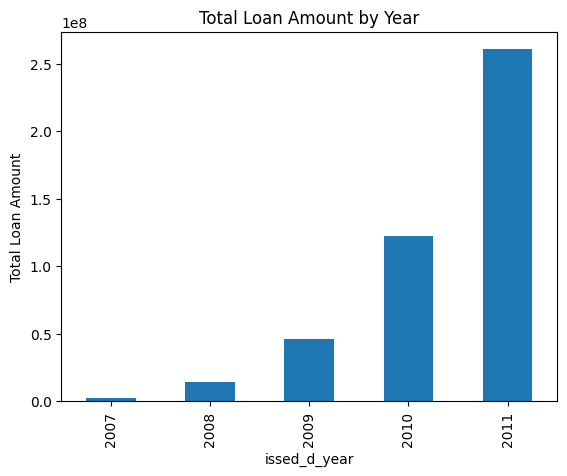

In [ ]:
year_summary['total_loan_amount'].plot(kind='bar')
plt.title("Total Loan Amount by Year")
plt.ylabel("Total Loan Amount")
plt.show()

In [ ]:
df_lec.loc['years' in 'emp_length_clean']

KeyError: 'False: boolean label can not be used without a boolean index'

In [ ]:
df_lec['emp_length_clean'].value_counts(dropna=False)

,count
emp_length_clean,
10,8879
0,4583
2 years,4388
3 years,4095
4 years,3436
5 years,3282
1 year,3240
6 years,2229
7 years,1773


In [ ]:
df_lec['int_rate_clean'] = df['int_rate'].copy()

/tmp/ipykernel_13428/3581527734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['int_rate_clean'] = df['int_rate'].copy()


In [ ]:
df_lec['int_rate_clean']

,int_rate_clean
0,10.65%
1,15.27%
2,15.96%
3,13.49%
4,12.69%
...,...
39712,8.07%
39713,10.28%
39714,8.07%
39715,7.43%


In [ ]:
df_lec['int_rate_clean'] = df['int_rate'].replace('%','')

/tmp/ipykernel_13428/2095047497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lec['int_rate_clean'] = df['int_rate'].replace('%','')


In [ ]:
df_lec['int_rate_clean']

,int_rate_clean
0,10.65%
1,15.27%
2,15.96%
3,13.49%
4,12.69%
...,...
39712,8.07%
39713,10.28%
39714,8.07%
39715,7.43%


In [ ]:
for column in df.columns:
  print(column)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_il_6m
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc

In [ ]:
df.describe(include="all")

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,...,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717,39717,39717.000000,39717,39717,37258,38642,39717,3.971700e+04,39717,39717,39717,39717,39717,26775,39717,39706,39717,39717,39717.000000,39717.000000,39717,39717.000000,14035.000000,2786.000000,39717.000000,39717.000000,39717.000000,39667,39717.000000,39717,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39646,39717.000000,1140,39715,39661.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39661.0,39717.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39020.000000,39678.0,0.0,0.0,0.0,0.0
unique,NaN,NaN,NaN,NaN,NaN,2,371,NaN,7,35,28820,11,5,NaN,3,55,3,1,39717,26526,14,19615,823,50,NaN,NaN,526,NaN,NaN,NaN,NaN,NaN,NaN,1089,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101,NaN,2,106,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,36 months,10.99%,NaN,B,B3,US Army,10+ years,RENT,NaN,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,,debt_consolidation,Debt Consolidation,100xx,CA,NaN,NaN,Nov-98,NaN,NaN,NaN,NaN,NaN,NaN,0%,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May-16,NaN,Jun-16,May-16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,29096,956,NaN,12020,2917,134,8879,18899,NaN,16921,2260,32950,39717,1,210,18641,2184,597,7099,NaN,NaN,370,NaN,NaN,NaN,NaN,NaN,NaN,977,NaN,39717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1256,NaN,1125,10308,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,NaN,NaN,324.561922,NaN,NaN,NaN,NaN,NaN,6.896893e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.315130,0.146512,NaN,0.869200,35.900962,69.698134,9.294408,0.055065,13382.528086,NaN,22.088828,NaN,51.227887,50.989768,12153.596544,11567.149118,9793.348813,2263.663172,1.363015,95.221624,12.406112,NaN,2678.826162,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Data Exploration: What kind of dataset is this?

Before cleaning anything, spend a little time understanding the dataset itself.

This CSV contains **loan application / loan performance** records from Lending Club. Each row is one loan, and the columns describe things such as:

- the **size of the loan** (`loan_amnt`)
- the **interest rate** (`int_rate`)
- the **borrower's employment length** (`emp_length`)
- the **borrower's income** (`annual_inc`)
- the **loan issue date** (`issue_d`)
- the **loan purpose** (`purpose`)
- the **borrower's state** (`addr_state`)
- the **loan outcome / repayment status** (`loan_status`)

### Why this dataset is useful
This is a good business dataset because it lets us connect:
- borrower characteristics,
- loan terms,
- and eventual repayment outcomes.

That makes it useful for both:
1. **exploratory data analysis** (what patterns do we see?), and
2. **risk modeling** (can we predict which loans are riskier?).

### What does "messy" mean here?
Real datasets are often not immediately ready for analysis. In this file, "messy" shows up in several ways:

- Some columns that **should be numeric are stored as text**, such as:
  - `int_rate` values like `"13.56%"`
  - `emp_length` values like `"10+ years"` or `"< 1 year"`
  - `term` values like `" 36 months"`
- Some columns that **represent dates are stored as strings**, such as `issue_d` values like `"Dec-11"`.
- Some columns have **missing values**.
- Some columns are **not equally useful** for this assignment. For example:
  - `url` is probably not useful for analysis
  - `desc` may be interesting, but it is harder to analyze in an introductory pandas assignment
  - columns like `loan_status`, `loan_amnt`, `int_rate`, `emp_length`, `annual_inc`, `purpose`, and `addr_state` are much more directly useful

### What does "cleaning it up" mean?
For this homework, cleaning means preparing the dataset so that important columns can actually be analyzed:

- turning text columns into numeric columns when appropriate
- turning date-like strings into proper datetime values
- handling missing values
- checking that the cleaned results make sense
- creating a smaller, more analysis-ready / model-ready dataset

### Your job in this section
Use pandas to explore the raw dataset before you start cleaning. Then answer the prompt questions below in code and short written responses.


In [ ]:

# Data exploration: your code here

# Suggested starting ideas:
# 1. Look at df.info()
# 2. Look at df.describe(include="all")
# 3. Count missing values in selected columns
# 4. Print unique values from columns like emp_length, int_rate, term, and loan_status
# 5. Identify which columns seem most useful for a risk-related analysis



### Data Exploration Questions

Answer these in the notebook using a mix of code output and short written responses.

1. How many rows and columns are in the dataset?
2. Which columns already look numeric, and which important ones are still stored as text?
3. Give **at least three examples** of "messy" columns and explain what makes them messy.
4. Which **5 to 8 columns** seem most useful for studying loan risk, and why?
5. Which columns seem less useful for this assignment, and why?
6. What do you think will need to be cleaned before this dataset is ready for machine learning?

You do **not** need to clean everything in the dataset. Part of data science is deciding which columns are worth focusing on.


## Task 1: Clean Employment Length (**No Regex**)

The `emp_length` column contains values such as:
- `"10+ years"`
- `"< 1 year"`
- `"3 years"`
- `"1 year"`

Your goal is to create a **new numeric column** named `emp_length_clean`.

### Requirements
1. Convert `emp_length` into a numeric form:
   - `"10+ years"` → `10`
   - `"< 1 year"` → `0`
   - `"3 years"` → `3`
   - `"1 year"` → `1`
2. You may use string methods such as `.replace()`, `.strip()`, or `.split()`.
3. **Do not use regex.**
4. Fill missing values in `emp_length_clean` using the **mode** of that cleaned column.
5. Print:
   - the unique raw values from `emp_length`,
   - the unique cleaned values from `emp_length_clean`,
   - the mode you used,
   - and the dtype of the cleaned column.

### Deliverable
At the end of the cell, briefly explain in 1–2 sentences why this cleaning matters for later analysis or machine learning.


In [ ]:

# Task 1: your code here


## Task 2: Clean Interest Rate

The `int_rate` column is stored as text such as `"13.56%"`.

Create a **new numeric column** named `int_rate_clean`.

### Requirements
1. Remove the percent sign.
2. Convert the result to a numeric type.
3. Print the dtype of `int_rate_clean`.
4. Print the following summary statistics:
   - mean
   - median
   - minimum
   - maximum

### Analysis
Compare the **average interest rate** for the following two groups:
- `Fully Paid`
- `Charged Off`

### Deliverable
Write 2–3 sentences describing whether higher interest rates appear to be associated with worse repayment outcomes.


In [ ]:

# Task 2: your code here


## Task 3: Temporal Engineering

The `issue_d` column is currently stored as text. The analytics team wants proper time-based features.

### Requirements
1. Convert `issue_d` into a datetime column.
2. Create two new columns:
   - `issue_year`
   - `issue_month`
3. Determine:
   - the number of loans issued in each year,
   - the total dollar amount of loans issued in each year.
4. Identify **which year had the highest total loan amount issued**.

### Visualization
Create **one chart** showing the **total loan amount by year**.

### Deliverable
Write 2–3 sentences summarizing the main pattern you see in the yearly loan totals.


In [ ]:

# Task 3: your code here


## Task 4: State-Level Default Risk

The Risk team wants to know which states appear riskiest.

For this assignment, define a **defaulted loan** as a loan with:

`loan_status == "Charged Off"`

### Requirements
1. Create a summary table by `addr_state`.
2. Your table must include:
   - total number of loans,
   - number of charged-off loans,
   - default ratio.
3. Filter out any states with **fewer than 100 loans**.
4. Identify the **top 5 riskiest states** by default ratio.

### Visualization
Create **one bar chart** showing the **top 10 states by default ratio** after applying the 100-loan filter.

### Deliverable
Write 2–3 sentences explaining which states seem riskiest and why the 100-loan filter is important.


In [ ]:

# Task 4: your code here


## Task 5: Employment Length and Repayment

Now investigate whether employment length appears related to repayment outcomes.

### Requirements
1. Group the data by `emp_length_clean`.
2. For each employment-length group, compute:
   - total loans,
   - charged-off loans,
   - default ratio.
3. Identify which employment-length group has the **highest default ratio**.

### Visualization
Create a **bar chart** of default ratio by `emp_length_clean`.

### Deliverable
Write 2–3 sentences answering this question:

**Does employment length appear to be related to repayment risk?**

Use numbers from your table.


In [ ]:

# Task 5: your code here


## Task 6: Create a Model-Ready Dataset

The machine learning team wants a cleaner dataset for a future predictive model.

Create a new dataframe called `df_model`.

### Requirements
1. Keep only rows where `loan_status` is either:
   - `Fully Paid`
   - `Charged Off`
2. Keep only the following columns:
   - `loan_amnt`
   - `term`
   - `int_rate_clean`
   - `emp_length_clean`
   - `home_ownership`
   - `annual_inc`
   - `purpose`
   - `addr_state`
   - `issue_year`
   - `issue_month`
   - `loan_status`
3. Drop rows with missing values in these selected columns.
4. Print the shape of `df_model`.
5. Save the result to a CSV file named:

`loan_data_model_ready.csv`

### Deliverable
Write 2–3 sentences explaining why a separate cleaned dataset is useful before building a machine learning model.


In [ ]:

# Task 6: your code here


## Task 7: Boardroom Memo

Write a short memo (about 1 paragraph per question, or a well-written bulleted memo) for the **Chief Risk Officer**.

Your memo must answer all of the following:

1. What did you clean in this dataset, and why did that cleaning matter?
2. Which state appears riskiest after applying the minimum-loan filter?
3. Does employment length appear related to default risk? Use specific evidence.
4. Are higher interest rates associated with worse repayment outcomes?
5. Why is this dataset now more useful for a future machine learning model?

Write your memo in the markdown cell below.


### Your memo goes here

- Replace this text with your memo.
